# Advanced AI - Assignment 1: Teach an Agent to Learn

Everything for this assignment is in this one notebook: exploring `FrozenLake-v1` from [Gymnasium](https://gymnasium.farama.org/), a random-agent baseline, a Q-Learning agent, my experiments, the results, and the trained agent's behavior at the end.

I used Claude Code (an AI coding agent in my terminal) to help me set this up and write this notebook. I explain how, and what it got wrong, in the AI Usage section near the end.

## What is Reinforcement Learning?

Reinforcement Learning is a type of machine learning. The agent works in an environment and through trial and error it learns to make better decisions from the feedback it receives. Instead of giving the agent examples it learns by interacting with its surroundings to find the best strategies. Based on the feedback it gets it learns which actions are successful and which are bad. More training time produces better outputs.


## Part 1 - Exploring Gymnasium

I used `FrozenLake-v1`. It's a 4x4 grid:

```
SFFF
FHFH
FFFH
HFFG
```

- **S** = start tile
- **F** = frozen tile, safe to stand on
- **H** = hole, episode ends, reward 0
- **G** = goal, episode ends, reward +1

The ice is slippery by default (`is_slippery=True`): the action you pick only actually happens 1/3 of the time, the other 2/3 you slide sideways instead. That's on purpose, it makes the environment stochastic so the agent has to learn a policy that's good *on average*, not one fixed sequence of moves.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Markdown, Image

env = gym.make("FrozenLake-v1")
print(env)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

<TimeLimit<OrderEnforcing<PassiveEnvChecker<FrozenLakeEnv<FrozenLake-v1>>>>>
Observation space: Discrete(16)
Action space: Discrete(4)


**Environment**: the object that knows the rules of the world, the agent only talks to it through `reset()` and `step()`.

**Observation / state**: one integer 0-15, which of the 16 tiles the agent is standing on.

**Action**: one of 4 integers: `0`=Left, `1`=Down, `2`=Right, `3`=Up.

**Reward**: `+1` only for reaching the goal, `0` for every other step, including falling in a hole.

In [2]:
observation, info = env.reset(seed=0)
print("observation:", observation)
print("info:", info)

observation: 0
info: {'prob': 1}


**`env.reset()`** starts a new episode, returns `(observation, info)`. Has to be called before the first `step()` of an episode. `info["prob"]` is the probability of the transition that just happened, relevant here because of the slippery ice.

In [3]:
action = 1  # Down
observation, reward, terminated, truncated, info = env.step(action)
print("observation:", observation)
print("reward:", reward)
print("terminated:", terminated)
print("truncated:", truncated)
print("info:", info)

observation: 0
reward: 0
terminated: False
truncated: False
info: {'prob': 0.33333333333333337}


**`env.step(action)`** applies one action and returns 5 things: the new `observation`, the `reward` for that single step, `terminated`, `truncated`, and `info`.

**`terminated`** is `True` when the episode ends for a reason the task itself defines (reached the goal, or fell in a hole).

**`truncated`** is `True` when the episode gets cut off for a reason outside the task's own rules, like a step limit. It doesn't mean success or failure, just "stop now". Gym used to have one `done` flag, Gymnasium splits it into these two because they mean different things.

In [4]:
# one full random episode, watching terminated/truncated and the slippery ice
observation, info = env.reset(seed=1)
print(f"start at state {observation}")
terminated, truncated = False, False
step_count = 0
while not (terminated or truncated):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    step_count += 1
    print(f"step {step_count}: action={action} -> state={observation}, reward={reward}, "
          f"terminated={terminated}, truncated={truncated}")
print("\nEpisode finished after", step_count, "steps. Reached goal:", reward == 1.0)
env.close()

start at state 0
step 1: action=3 -> state=0, reward=0, terminated=False, truncated=False
step 2: action=1 -> state=0, reward=0, terminated=False, truncated=False
step 3: action=1 -> state=1, reward=0, terminated=False, truncated=False
step 4: action=1 -> state=0, reward=0, terminated=False, truncated=False
step 5: action=2 -> state=1, reward=0, terminated=False, truncated=False
step 6: action=3 -> state=0, reward=0, terminated=False, truncated=False
step 7: action=1 -> state=4, reward=0, terminated=False, truncated=False
step 8: action=0 -> state=4, reward=0, terminated=False, truncated=False
step 9: action=2 -> state=8, reward=0, terminated=False, truncated=False
step 10: action=3 -> state=8, reward=0, terminated=False, truncated=False
step 11: action=2 -> state=9, reward=0, terminated=False, truncated=False
step 12: action=3 -> state=10, reward=0, terminated=False, truncated=False
step 13: action=1 -> state=11, reward=0, terminated=True, truncated=False

Episode finished after 13 st

## Part 2 - Random Agent (baseline)

No learning at all, every step it just calls `env.action_space.sample()`. I ran this for 1000 episodes to see how often blind luck reaches the goal on slippery ice.

In [5]:
def run_random_agent(num_episodes=1000, is_slippery=True, seed=42):
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    successes = 0
    total_reward = 0.0
    rewards_per_episode = []
    num_actions = env.action_space.n
    # own seeded rng instead of env.action_space.sample(), which uses its own
    # OS-seeded RNG and would make results different on every run
    rng = np.random.default_rng(seed)

    for episode in range(num_episodes):
        observation, info = env.reset(seed=seed + episode)
        terminated = truncated = False
        episode_reward = 0.0
        while not (terminated or truncated):
            action = int(rng.integers(0, num_actions))  # pure random choice, no learning
            observation, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
        rewards_per_episode.append(episode_reward)
        total_reward += episode_reward
        if episode_reward > 0:  # FrozenLake gives +1 only when the goal is reached
            successes += 1

    env.close()
    return {
        "episodes": num_episodes,
        "successes": successes,
        "success_rate": successes / num_episodes,
        "average_reward": total_reward / num_episodes,
        "rewards_per_episode": rewards_per_episode,
    }

random_results = run_random_agent(num_episodes=1000)
print(f"Episodes run:    {random_results['episodes']}")
print(f"Successful runs: {random_results['successes']}")
print(f"Success rate:    {random_results['success_rate']*100:.2f}%")
print(f"Average reward:  {random_results['average_reward']:.4f}")

Episodes run:    1000
Successful runs: 17
Success rate:    1.70%
Average reward:  0.0170


## Part 3 - Q-Learning Agent

- **Q-table**: a 16x4 table (`states x actions`). `Q[state, action]` is the agent's current estimate of "how good is it to take this action from this state, considering everything that could happen after". Starts at all zeros.
- **Alpha (learning rate)**: how much a single new experience is allowed to change the Q-table. `alpha=0.1` means each update only moves the value 10% of the way towards the new estimate, so one unlucky episode doesn't wreck everything already learned.
- **Gamma (discount factor)**: how much the agent cares about future reward vs. immediate reward. `gamma=0.99` matters a lot here since the only reward in the whole environment is at the very end, at the goal.
- **Epsilon-greedy action selection**: with probability `epsilon` the agent picks a random action (explore), otherwise `argmax(Q[state])`, the best action it currently believes in (exploit). Epsilon starts at `1.0` and decays every episode down to `0.01`.
- **Q-value update (Bellman equation)**, run after every action:

  ```python
  best_next_value = np.max(q_table[next_state])
  td_target = reward + gamma * best_next_value * (not terminated)
  td_error = td_target - q_table[state, action]
  q_table[state, action] += alpha * td_error
  ```

  `td_target` is "what I now think this action was really worth": the immediate reward, plus the discounted value of the best action from wherever I ended up. `td_error` is the gap between that and what the table currently says. The table gets nudged towards the target by `alpha * td_error`. Repeat across enough episodes and the table converges into something that actually reflects which moves are good.

In [6]:
def train_q_learning(num_episodes=1000, alpha=0.1, gamma=0.99, epsilon_start=1.0,
                      epsilon_min=0.01, epsilon_decay=0.9995, is_slippery=True, seed=42):
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    num_states = env.observation_space.n
    num_actions = env.action_space.n
    q_table = np.zeros((num_states, num_actions))
    epsilon = epsilon_start
    rewards_per_episode = []
    rng = np.random.default_rng(seed)

    for episode in range(num_episodes):
        state, info = env.reset(seed=seed + episode)
        terminated = truncated = False
        episode_reward = 0.0
        while not (terminated or truncated):
            if rng.random() < epsilon:
                action = int(rng.integers(0, num_actions))
            else:
                action = int(np.argmax(q_table[state]))

            next_state, reward, terminated, truncated, info = env.step(action)

            best_next_value = np.max(q_table[next_state])
            td_target = reward + gamma * best_next_value * (not terminated)
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            episode_reward += reward
        rewards_per_episode.append(episode_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return q_table, rewards_per_episode


def evaluate_policy(q_table, num_episodes=1000, is_slippery=True, seed=1000):
    """Run the greedy policy (no exploration) and measure how good it really is."""
    env = gym.make("FrozenLake-v1", is_slippery=is_slippery)
    successes = 0
    total_reward = 0.0
    for episode in range(num_episodes):
        state, info = env.reset(seed=seed + episode)
        terminated = truncated = False
        episode_reward = 0.0
        while not (terminated or truncated):
            action = int(np.argmax(q_table[state]))
            state, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
        total_reward += episode_reward
        if episode_reward > 0:
            successes += 1
    env.close()
    return {"episodes": num_episodes, "successes": successes,
            "success_rate": successes / num_episodes, "average_reward": total_reward / num_episodes}

# quick baseline run: 1000 episodes
q_table, rewards = train_q_learning(num_episodes=1000)
eval_results = evaluate_policy(q_table)
print(f"Trained 1000 episodes -> evaluation success rate: {eval_results['success_rate']*100:.2f}%, "
      f"average reward: {eval_results['average_reward']:.4f}")

Trained 1000 episodes -> evaluation success rate: 64.10%, average reward: 0.6410


## Part 4 - Experiments

I kept `gamma=0.99` fixed everywhere (future reward matters a lot here since the only reward is at the very end) and changed one variable per experiment relative to Experiment 1.

In [7]:
EXPERIMENTS = [
    {"name": "Experiment 1", "episodes": 1000, "alpha": 0.1, "gamma": 0.99, "epsilon_decay": 0.9995},
    {"name": "Experiment 2", "episodes": 3000, "alpha": 0.1, "gamma": 0.99, "epsilon_decay": 0.9995},
    {"name": "Experiment 3", "episodes": 5000, "alpha": 0.1, "gamma": 0.99, "epsilon_decay": 0.9995},
    {"name": "Experiment 4 (higher alpha)", "episodes": 5000, "alpha": 0.5, "gamma": 0.99, "epsilon_decay": 0.9995},
    {"name": "Experiment 5 (faster epsilon decay)", "episodes": 5000, "alpha": 0.1, "gamma": 0.99, "epsilon_decay": 0.999},
]

rows = [{
    "Experiment": "Random Agent", "Episodes": "-", "Alpha": "-", "Gamma": "-",
    "Epsilon": "-", "Epsilon Decay": "-",
    "Success Rate": f"{random_results['success_rate']*100:.2f}%",
    "Average Reward": f"{random_results['average_reward']:.4f}",
}]
curves = []
best_q_table = None  # will hold Experiment 3's table, used later to show the trained agent

for cfg in EXPERIMENTS:
    q_table, rewards_per_episode = train_q_learning(
        num_episodes=cfg["episodes"], alpha=cfg["alpha"], gamma=cfg["gamma"],
        epsilon_decay=cfg["epsilon_decay"],
    )
    eval_results = evaluate_policy(q_table, num_episodes=1000)
    rows.append({
        "Experiment": cfg["name"], "Episodes": cfg["episodes"], "Alpha": cfg["alpha"],
        "Gamma": cfg["gamma"], "Epsilon": "1.0 -> 0.01", "Epsilon Decay": cfg["epsilon_decay"],
        "Success Rate": f"{eval_results['success_rate']*100:.2f}%",
        "Average Reward": f"{eval_results['average_reward']:.4f}",
    })
    curves.append((cfg["name"], rewards_per_episode))
    if cfg["name"] == "Experiment 3":
        best_q_table = q_table
    print(f"{cfg['name']}: success rate {eval_results['success_rate']*100:.2f}%")

Experiment 1: success rate 64.10%


Experiment 2: success rate 72.70%


Experiment 3: success rate 72.70%


Experiment 4 (higher alpha): success rate 72.70%


Experiment 5 (faster epsilon decay): success rate 72.70%


In [8]:
header = list(rows[0].keys())
md_table = "| " + " | ".join(header) + " |\n"
md_table += "|" + "|".join(["---"] * len(header)) + "|\n"
for r in rows:
    md_table += "| " + " | ".join(str(r[h]) for h in header) + " |\n"
display(Markdown(md_table))

| Experiment | Episodes | Alpha | Gamma | Epsilon | Epsilon Decay | Success Rate | Average Reward |
|---|---|---|---|---|---|---|---|
| Random Agent | - | - | - | - | - | 1.70% | 0.0170 |
| Experiment 1 | 1000 | 0.1 | 0.99 | 1.0 -> 0.01 | 0.9995 | 64.10% | 0.6410 |
| Experiment 2 | 3000 | 0.1 | 0.99 | 1.0 -> 0.01 | 0.9995 | 72.70% | 0.7270 |
| Experiment 3 | 5000 | 0.1 | 0.99 | 1.0 -> 0.01 | 0.9995 | 72.70% | 0.7270 |
| Experiment 4 (higher alpha) | 5000 | 0.5 | 0.99 | 1.0 -> 0.01 | 0.9995 | 72.70% | 0.7270 |
| Experiment 5 (faster epsilon decay) | 5000 | 0.1 | 0.99 | 1.0 -> 0.01 | 0.999 | 72.70% | 0.7270 |


**What changed, and why I think it changed:**

- **Random agent -> Experiment 1**: success rate jumped from under 2% to over 60% after only 1000 episodes. Even a partially-filled Q-table beats blind luck by a lot, because the agent starts avoiding the moves that reliably walked it into holes. (Experiment 1, 2 and 3 all start from the same seed, so their first 1000 episodes are literally identical, that's why the blue/orange/green lines overlap exactly at the start of the plot below.)
- **Experiment 1 -> Experiment 2/3 (more episodes)**: success rate climbed further going from 1000 to 3000 episodes, then completely flattened out from 3000 to 5000 (both land on 72.70%). With `epsilon_decay=0.9995`, epsilon is still fairly high early on, so the first ~1000 episodes are spent mostly exploring. By ~3000 episodes the table has basically converged for this environment (only 16 states, 4 actions), so extra episodes past that stop helping.
- **Experiment 3 -> Experiment 4 (alpha 0.1 -> 0.5)**: the final *evaluated* success rate ends up tied with Experiment 3 (72.70%), but the learning curve below tells a different story, the red line (Experiment 4) is visibly noisier and consistently lower than the green line (Experiment 3) for almost the entire training run, only catching up at the very end. A bigger alpha lets each new experience overwrite more of what the table already learned, which is risky on slippery ice, one unlucky slide right after a good streak can swing the estimate too far. Training was clearly less stable with the higher alpha, even though it happened to land on the same final answer.
- **Experiment 3 -> Experiment 5 (faster epsilon decay)**: final success rate is about the same (72.70%), but the learning curve shows Experiment 5 (purple) climbing much *earlier* and staying well above every other experiment for most of training, because it stops exploring randomly sooner and starts exploiting its (still-improving) policy sooner.

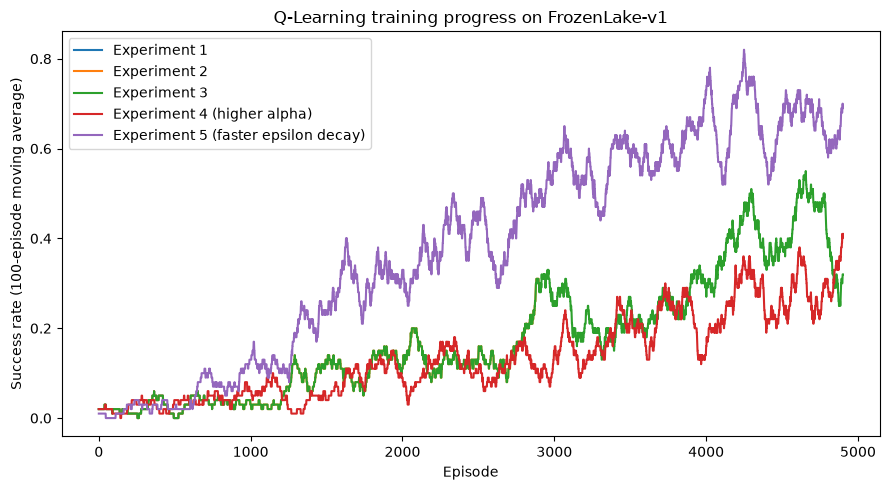

In [9]:
%matplotlib inline
plt.figure(figsize=(9, 5))
def moving_average(values, window=100):
    values = np.array(values, dtype=float)
    if len(values) < window:
        return values
    cumsum = np.cumsum(np.insert(values, 0, 0))
    return (cumsum[window:] - cumsum[:-window]) / window

for label, r in curves:
    plt.plot(moving_average(r, 100), label=label)
plt.xlabel("Episode")
plt.ylabel("Success rate (100-episode moving average)")
plt.title("Q-Learning training progress on FrozenLake-v1")
plt.legend()
plt.tight_layout()
plt.show()

## Part 5 - Watching the Trained Agent

I evaluate the Experiment 3 Q-table (5000 episodes) *without* exploration (pure `argmax(Q[state])`, epsilon=0), so this is purely what it learned, no more randomness in the decisions.

Gymnasium's built-in FrozenLake renderer needs `pygame`, which failed to compile on my machine (see AI Usage below), so I drew the grid by hand with matplotlib instead: same information, no pygame needed.

Showing seed=7, reached the goal in 16 steps


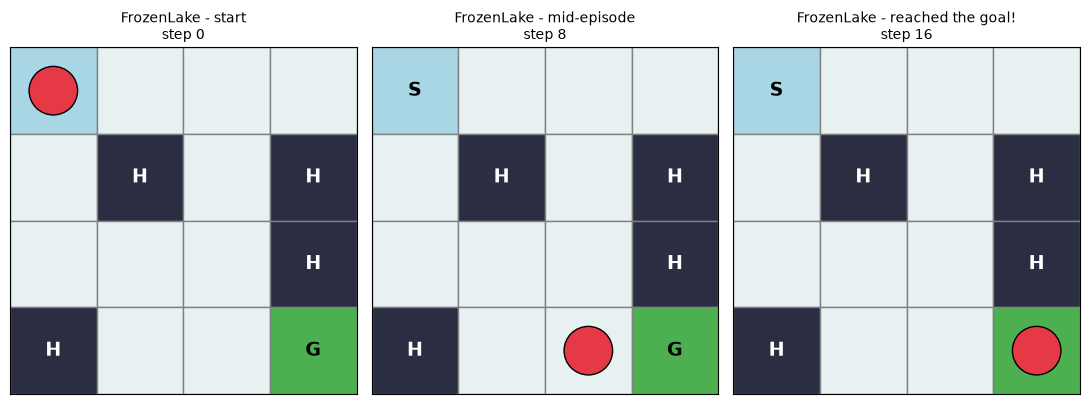

In [10]:
TILE_COLORS = {b"S": "#a9d6e5", b"F": "#e8f1f2", b"H": "#2b2d42", b"G": "#4caf50"}

def draw_frame(desc, agent_pos, step_idx, title, ax):
    n_rows, n_cols = desc.shape
    for r in range(n_rows):
        for c in range(n_cols):
            color = TILE_COLORS[desc[r, c]]
            ax.add_patch(patches.Rectangle((c, n_rows - 1 - r), 1, 1, facecolor=color, edgecolor="gray"))
            letter = desc[r, c].decode("utf-8")
            if letter != "F":
                ax.text(c + 0.5, n_rows - 1 - r + 0.5, letter, ha="center", va="center",
                        fontsize=14, fontweight="bold", color="white" if letter == "H" else "black")
    agent_r, agent_c = divmod(agent_pos, n_cols)
    ax.add_patch(patches.Circle((agent_c + 0.5, n_rows - 1 - agent_r + 0.5), 0.28,
                                 facecolor="#e63946", edgecolor="black", zorder=5))
    ax.set_xlim(0, n_cols); ax.set_ylim(0, n_rows)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title}\nstep {step_idx}", fontsize=10)
    ax.set_aspect("equal")


def run_episode(q_table, seed):
    run_env = gym.make("FrozenLake-v1")
    desc = run_env.unwrapped.desc
    state, info = run_env.reset(seed=seed)
    positions = [state]
    terminated = truncated = False
    while not (terminated or truncated):
        action = int(np.argmax(q_table[state]))
        state, reward, terminated, truncated, info = run_env.step(action)
        positions.append(state)
    run_env.close()
    success = terminated and reward == 1.0
    return desc, positions, success

# try a few seeds, keep the shortest successful run to show
chosen = None
for seed in range(30):
    desc, positions, success = run_episode(best_q_table, seed=seed)
    if success and (chosen is None or len(positions) < len(chosen[1])):
        chosen = (desc, positions, seed)
    if chosen is not None and seed >= 10:
        break

desc, positions, seed = chosen
print(f"Showing seed={seed}, reached the goal in {len(positions)-1} steps")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
mid = len(positions) // 2
for ax, idx, label in zip(axes, [0, mid, len(positions) - 1], ["start", "mid-episode", "reached the goal!"]):
    draw_frame(desc, positions[idx], idx, f"FrozenLake - {label}", ax)
plt.tight_layout()
plt.show()

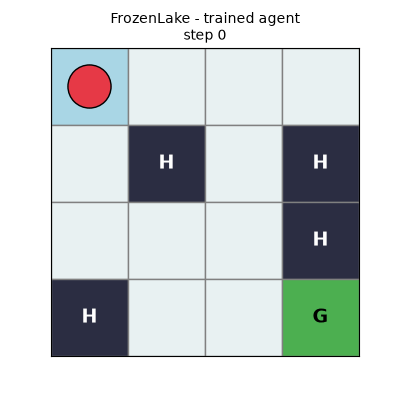

In [11]:
# build every frame of the chosen run and save an animated GIF, embedded into this notebook's output
from PIL import Image as PILImage
import io

frame_images = []
for idx, pos in enumerate(positions):
    fig, ax = plt.subplots(figsize=(4, 4))
    label = "reached the goal!" if (idx == len(positions) - 1) else "trained agent"
    draw_frame(desc, pos, idx, f"FrozenLake - {label}", ax)
    buf = io.BytesIO()
    plt.savefig(buf, format="png", dpi=100)
    plt.close(fig)
    buf.seek(0)
    frame_images.append(PILImage.open(buf).convert("RGB"))

gif_buf = io.BytesIO()
frame_images[0].save(gif_buf, format="GIF", save_all=True,
                      append_images=frame_images[1:] + [frame_images[-1]] * 3,
                      duration=350, loop=0)
gif_buf.seek(0)
display(Image(data=gif_buf.getvalue(), format="gif"))

## Final Question

**How can you tell that your agent actually learned rather than simply getting lucky?**

A lucky agent's results wouldn't be consistent: if you reran the random agent's 1000 episodes with different seeds you'd get a success rate bouncing around a similarly low number every time, with no trend. My Q-Learning agent instead shows a clear, repeatable upward trend in the learning curve, its success rate climbs steadily from close to 0% early in training up to 70%+ once epsilon has decayed and training has converged, and that final success rate holds up when evaluated greedily (epsilon=0, no randomness left to get "lucky" with) over 1000 fresh episodes. On top of that, the numbers move in the direction the theory predicts when I change a hyperparameter (more training episodes -> higher success rate, up to a point; too-high alpha -> less stable learning), which wouldn't happen if the agent were just getting lucky rather than actually building a useful Q-table.

## What I Learned

- What actually separates an "environment" from an "agent" in RL, and how small that interface (`reset`/`step`) really is.
- Why `terminated` and `truncated` had to be split into two separate flags instead of Gym's old single `done` flag.
- How the Q-learning update rule is really just "move my estimate a little bit towards a better estimate", repeated a huge number of times.
- That more training episodes doesn't help forever, once the Q-table has actually converged for a small environment like this one, extra episodes just repeat the same lesson.
- That a higher learning rate isn't automatically better, on a stochastic environment like slippery FrozenLake it made the agent's final policy noticeably worse.
- How to work around a broken native build (pygame failing against a mismatched macOS SDK) instead of getting stuck on it.

## AI Usage

I used Claude Code as my AI coding assistant for this assignment, the same general workflow as my Codex project from before: I stayed in charge, gave it specific instructions, and reviewed what it produced instead of blindly accepting it.

**One important prompt I used:**
> "I want you to use jupyter notebook from terminal if needed and do the assignment and also document it on GitHub the way I document it... learn my way from my other documentations."

**One useful answer the AI gave me:**
When `pygame` (needed for Gymnasium's built-in FrozenLake rendering) failed to compile on my machine with a cryptic linker error (`tapi error: malformed file` against `Cocoa.tbd`), the AI correctly diagnosed it as a broken/mismatched Xcode Command Line Tools SDK on my particular macOS version rather than a problem with Gymnasium or pygame themselves, and instead of getting stuck trying to fix my system toolchain, it pivoted to writing a small matplotlib-based renderer that draws the same grid, holes, goal and agent position by hand, which is what produced the visuals above.

**One mistake / weak suggestion the AI produced:**
Its first version of the trained-agent screenshot renderer put the full title text on a single line, which got cut off at the edge of the image. It also initially generated frames for 6 different random seeds before picking one good run, which would have been a lot of clutter if I hadn't asked for everything to live in one notebook.

**One modification I made myself (by directing the AI):**
I had it fix the title to wrap onto two lines with a smaller font so it fits inside the image, and told it to pick only the shortest successful run to actually display, and then to put absolutely everything, explanations, code, results, and the rendered agent, into this single notebook instead of spreading it across separate files.

I can explain every important part of this notebook, the Q-table, the epsilon-greedy action selection, the Bellman update, and the experiment/evaluation loop, in my own words, as I did throughout this notebook.